# Heart Disease Risk Prediction & Patient Clustering
### Cardiovascular Disease Dataset — 70,000 Patients, 12 Clinical Features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, concatenate
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE

import scipy.stats as stats
from scipy.cluster.hierarchy import dendrogram, linkage

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
print('All libraries imported successfully.')

All libraries imported successfully.


# Data Preprocessing

In [2]:
data = pd.read_csv('cardio_train.csv', sep=';')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
data.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
data.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## Convert age from days to years

In [7]:
data['age'] = (data['age'] / 365).astype(int)
print('Age range after conversion:', data['age'].min(), '-', data['age'].max(), 'years')

Age range after conversion: 29 - 64 years


## Handle outliers in blood pressure

In [8]:
before = len(data)
data = data[(data['ap_hi'] <= 250) & (data['ap_hi'] >= 60)]
print(f'Rows removed (ap_hi outliers): {before - len(data)}')

Rows removed (ap_hi outliers): 228


In [9]:
before = len(data)
data = data[(data['ap_lo'] <= 200) & (data['ap_lo'] >= 40)]
print(f'Rows removed (ap_lo outliers): {before - len(data)}')

Rows removed (ap_lo outliers): 997


In [10]:
before = len(data)
data = data[data['ap_hi'] >= data['ap_lo']]
print(f'Rows removed (ap_hi < ap_lo impossible values): {before - len(data)}')
print(f'Dataset size after outlier removal: {len(data)} rows')

Rows removed (ap_hi < ap_lo impossible values): 101
Dataset size after outlier removal: 68674 rows


## Remove duplicates

In [11]:
print('Duplicate rows:', data.duplicated().sum())

Duplicate rows: 0


In [12]:
data = data.drop_duplicates().reset_index(drop=True)
print(f'Dataset size after deduplication: {len(data)} rows')

Dataset size after deduplication: 68674 rows


## Encode categorical variables

In [13]:
# cholesterol and gluc are ordinal (1=normal, 2=above normal, 3=well above normal) — kept as-is
print('cholesterol value counts:')
print(data['cholesterol'].value_counts().sort_index())
print('\ngluc value counts:')
print(data['gluc'].value_counts().sort_index())

cholesterol value counts:
cholesterol
1    51502
2     9302
3     7870
Name: count, dtype: int64

gluc value counts:
gluc
1    58390
2     5067
3     5217
Name: count, dtype: int64


## Address class imbalance using SMOTE

In [14]:
print('Class balance before SMOTE:')
print(data['cardio'].value_counts())

Class balance before SMOTE:
cardio
0    34700
1    33974
Name: count, dtype: int64


In [15]:
X = data.drop(columns=['id', 'cardio'])
y = data['cardio']

In [16]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [17]:
print('Class balance after SMOTE:')
print(pd.Series(y_res).value_counts())

Class balance after SMOTE:
cardio
0    34700
1    34700
Name: count, dtype: int64


## Save dataEda before scaling

In [18]:
dataEda = pd.concat([X_res, y_res], axis=1).copy()
print('dataEda shape:', dataEda.shape)

dataEda shape: (69400, 12)


## Scale numerical features using RobustScaler

In [19]:
from sklearn.preprocessing import RobustScaler
numeric_features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
scaler = RobustScaler()
X_res[numeric_features] = scaler.fit_transform(X_res[numeric_features])

In [20]:
data = pd.concat([X_res, y_res], axis=1).reset_index(drop=True)
data.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,-0.3,2,0.272727,-0.588235,-0.5,0.0,1,1,0,0,1,0
1,0.2,1,-0.818182,0.764706,1.0,1.0,3,1,0,0,1,1
2,-0.2,1,0.000000,-0.470588,0.5,-1.0,3,1,0,0,0,1
3,-0.5,2,0.363636,0.588235,1.5,2.0,1,1,0,0,1,1
4,-0.6,1,-0.818182,-0.941176,-1.0,-2.0,1,1,0,0,0,0


# Exploratory Data Analysis
    - USE dataEda for the Exploratory

# Correlation analysis between all clinical features and cardiovascular disease

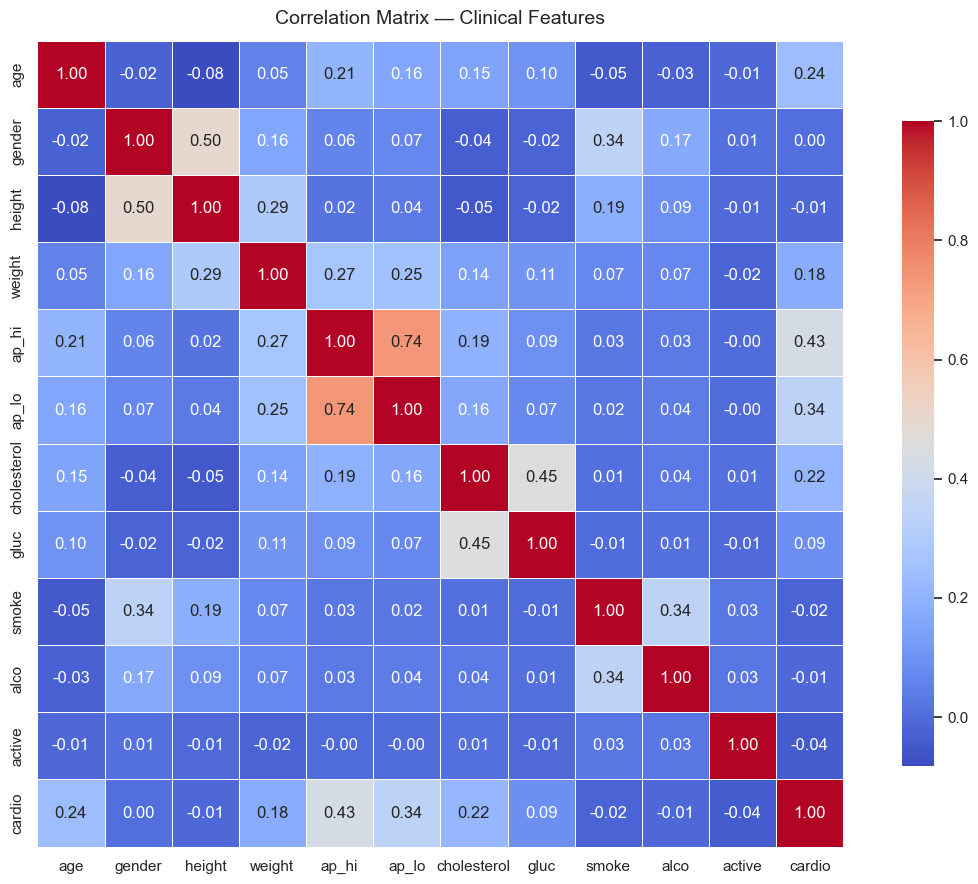

In [21]:
plt.figure(figsize=(12, 9))
corr_matrix = dataEda.corr()
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — Clinical Features', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Age distribution with 5-year bins and disease prevalence

In [22]:
age_bins = range(int(dataEda['age'].min()), int(dataEda['age'].max()) + 6, 5)
age_labels = [f'{b}-{b+4}' for b in age_bins][:-1]
dataEda['age_group'] = pd.cut(dataEda['age'], bins=age_bins, labels=age_labels, right=False)

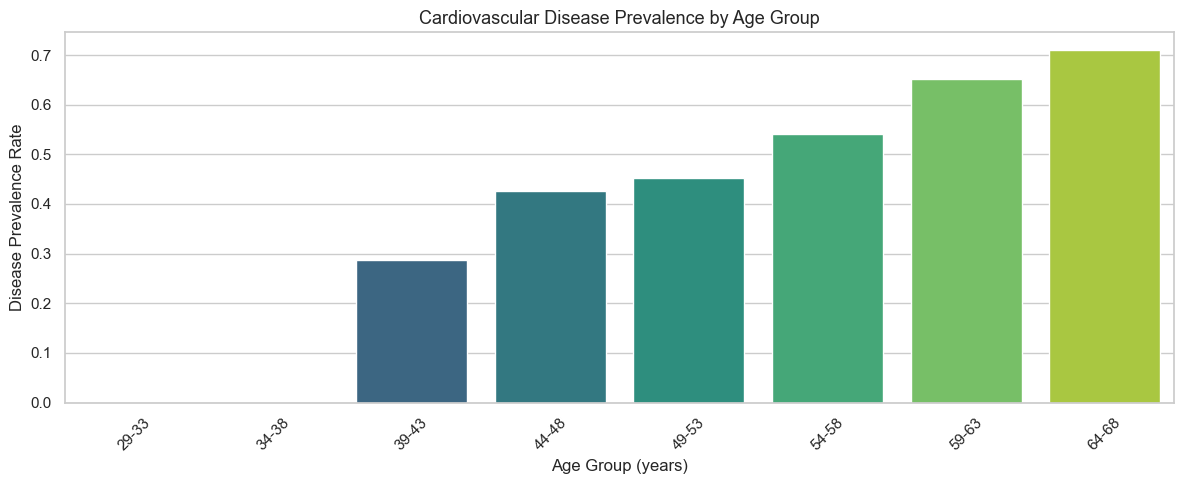

In [23]:
age_prevalence = dataEda.groupby('age_group', observed=True)['cardio'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=age_prevalence, x='age_group', y='cardio', palette='viridis')
plt.title('Cardiovascular Disease Prevalence by Age Group', fontsize=13)
plt.xlabel('Age Group (years)')
plt.ylabel('Disease Prevalence Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Blood pressure category visualization

In [24]:
def classify_bp(row):
    if row['ap_hi'] < 120 and row['ap_lo'] < 80:
        return 'Normal'
    elif (120 <= row['ap_hi'] <= 139) or (80 <= row['ap_lo'] <= 89):
        return 'Stage 1 Hypertension'
    else:
        return 'Stage 2 Hypertension'

dataEda['bp_category'] = dataEda.apply(classify_bp, axis=1)
print(dataEda['bp_category'].value_counts())

bp_category
Stage 1 Hypertension    44386
Stage 2 Hypertension    15413
Normal                   9601
Name: count, dtype: int64


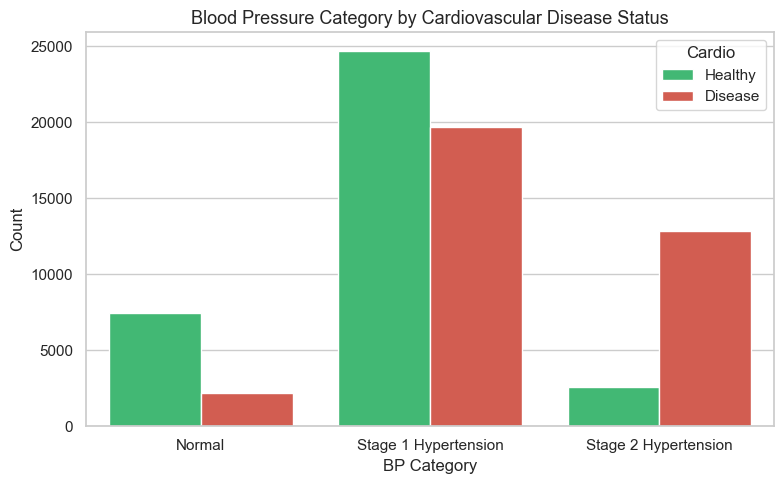

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=dataEda, x='bp_category', hue='cardio',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    order=['Normal', 'Stage 1 Hypertension', 'Stage 2 Hypertension']
)
plt.title('Blood Pressure Category by Cardiovascular Disease Status', fontsize=13)
plt.xlabel('BP Category')
plt.ylabel('Count')
plt.legend(title='Cardio', labels=['Healthy', 'Disease'])
plt.tight_layout()
plt.show()

# Interactive Plotly dashboard - risk factor combinations

In [26]:
import plotly.express as px

In [27]:
plot_sample = dataEda.sample(5000, random_state=42)
fig = px.scatter(
    plot_sample, x='ap_hi', y='ap_lo', color='cardio',
    color_discrete_map={0: '#2ecc71', 1: '#e74c3c'},
    title='Systolic vs Diastolic Blood Pressure by Disease Status',
    labels={'ap_hi': 'Systolic BP (ap_hi)', 'ap_lo': 'Diastolic BP (ap_lo)', 'cardio': 'Cardio'},
    opacity=0.5
)
fig.show()

In [28]:
fig_age = px.box(
    dataEda, x='cardio', y='age', color='cardio',
    color_discrete_map={0: '#2ecc71', 1: '#e74c3c'},
    title='Age Distribution by Cardiovascular Disease Status',
    labels={'cardio': 'Cardio (0=Healthy, 1=Disease)', 'age': 'Age (years)'}
)
fig_age.show()

In [29]:
fig_weight = px.box(
    dataEda, x='cardio', y='weight', color='cardio',
    color_discrete_map={0: '#2ecc71', 1: '#e74c3c'},
    title='Weight Distribution by Cardiovascular Disease Status',
    labels={'cardio': 'Cardio (0=Healthy, 1=Disease)', 'weight': 'Weight (kg)'}
)
fig_weight.show()

# Statistical significance testing

In [30]:
# Chi-square test: cholesterol vs cardio
contingency_table = pd.crosstab(dataEda['cholesterol'], dataEda['cardio'])
chi2, p_chol, dof, expected = stats.chi2_contingency(contingency_table)
print(f'Chi-Square Test (cholesterol vs cardio):')
print(f'  chi2 = {chi2:.4f}, p-value = {p_chol:.4e}, dof = {dof}')
print(f'  Result: {"Significant" if p_chol < 0.05 else "Not significant"} (alpha=0.05)')

Chi-Square Test (cholesterol vs cardio):
  chi2 = 3295.7382, p-value = 0.0000e+00, dof = 2
  Result: Significant (alpha=0.05)


In [31]:
# T-test: age between cardio=0 and cardio=1
age_healthy = dataEda[dataEda['cardio'] == 0]['age']
age_disease = dataEda[dataEda['cardio'] == 1]['age']
t_age, p_age = stats.ttest_ind(age_healthy, age_disease)
print(f'T-test (age — healthy vs disease):')
print(f'  t = {t_age:.4f}, p-value = {p_age:.4e}')
print(f'  Result: {"Significant" if p_age < 0.05 else "Not significant"} (alpha=0.05)')

T-test (age — healthy vs disease):
  t = -64.7331, p-value = 0.0000e+00
  Result: Significant (alpha=0.05)


In [32]:
# T-test: ap_hi between cardio=0 and cardio=1
aphi_healthy = dataEda[dataEda['cardio'] == 0]['ap_hi']
aphi_disease = dataEda[dataEda['cardio'] == 1]['ap_hi']
t_aphi, p_aphi = stats.ttest_ind(aphi_healthy, aphi_disease)
print(f'T-test (ap_hi — healthy vs disease):')
print(f'  t = {t_aphi:.4f}, p-value = {p_aphi:.4e}')
print(f'  Result: {"Significant" if p_aphi < 0.05 else "Not significant"} (alpha=0.05)')

T-test (ap_hi — healthy vs disease):
  t = -124.5760, p-value = 0.0000e+00
  Result: Significant (alpha=0.05)


# Lifestyle factor analysis

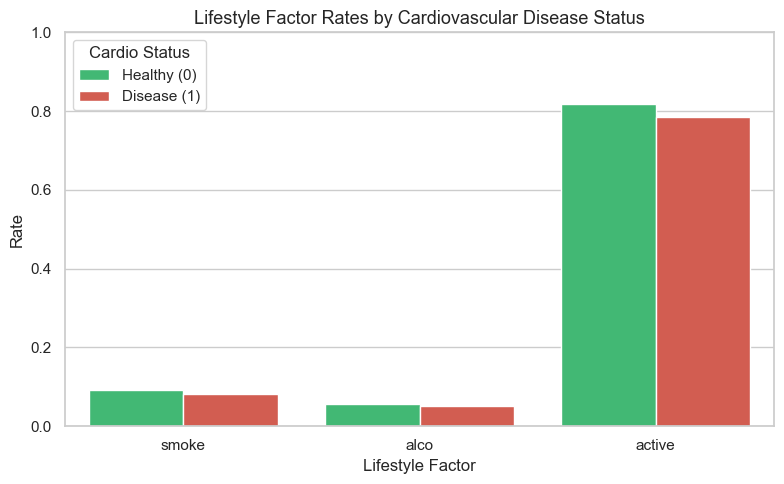

In [33]:
lifestyle_cols = ['smoke', 'alco', 'active']
lifestyle_rates = dataEda.groupby('cardio')[lifestyle_cols].mean().T.reset_index()
lifestyle_rates.columns = ['Factor', 'Healthy (0)', 'Disease (1)']

lifestyle_melted = lifestyle_rates.melt(id_vars='Factor', var_name='Cardio Status', value_name='Rate')

plt.figure(figsize=(8, 5))
sns.barplot(data=lifestyle_melted, x='Factor', y='Rate', hue='Cardio Status',
            palette={'Healthy (0)': '#2ecc71', 'Disease (1)': '#e74c3c'})
plt.title('Lifestyle Factor Rates by Cardiovascular Disease Status', fontsize=13)
plt.ylabel('Rate')
plt.xlabel('Lifestyle Factor')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Unsupervised ML

> K-Means

In [34]:
x = data[['age', 'weight', 'ap_hi', 'ap_lo', 'cholesterol']]
x_scaled = StandardScaler().fit_transform(x)

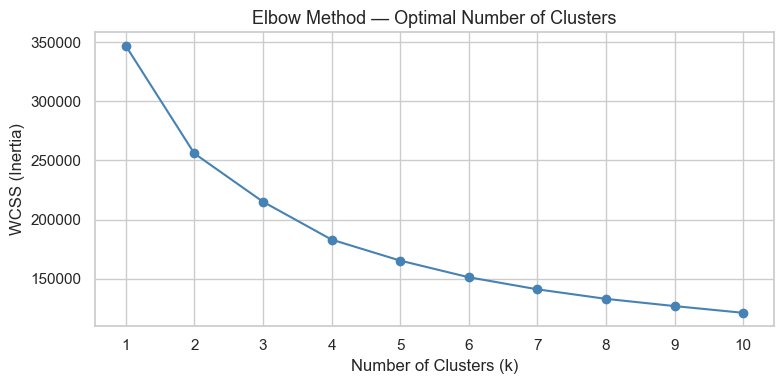

In [35]:
# Elbow method — WCSS for k=1 to 10
wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [36]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(x_scaled)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [37]:
data['kmean'] = kmeans.predict(x_scaled)
print('KMeans cluster distribution:')
print(data['kmean'].value_counts().sort_index())

KMeans cluster distribution:
kmean
0    19567
1    10409
2     8886
3     7672
4     9061
5    13805
Name: count, dtype: int64


> DBSCAN

In [38]:
from sklearn.cluster import DBSCAN

In [39]:
dbscan = DBSCAN(eps=0.5, min_samples=10)

In [40]:
data['dbscan'] = dbscan.fit_predict(x_scaled)
n_outliers = (data['dbscan'] == -1).sum()
print(f'Number of DBSCAN outliers (label = -1): {n_outliers}')
print('DBSCAN label distribution:')
print(data['dbscan'].value_counts().sort_index())

Number of DBSCAN outliers (label = -1): 4468
DBSCAN label distribution:
dbscan
-1      4468
 0     50033
 1      2337
 2      3621
 3      3310
 4        22
 5       516
 6      2365
 7      1101
 8       429
 9       226
 10      586
 11       15
 12      105
 13       34
 14       10
 15       18
 16       33
 17       11
 18        7
 19        8
 20       15
 21       22
 22       14
 23       10
 24       10
 25       40
 26       10
 27        5
 28       10
 29        9
Name: count, dtype: int64


> Hierarchical Clustering

In [41]:
from sklearn.cluster import AgglomerativeClustering

In [42]:
# Sample 3000 rows for speed
sample_idx = np.random.choice(len(x_scaled), size=3000, replace=False)
x_sample = x_scaled[sample_idx]

agg_clust = AgglomerativeClustering(n_clusters=6)
agg_labels = agg_clust.fit_predict(x_sample)
print('Agglomerative cluster label distribution:')
print(pd.Series(agg_labels).value_counts().sort_index())

Agglomerative cluster label distribution:
0    786
1    456
2    440
3    255
4    738
5    325
Name: count, dtype: int64


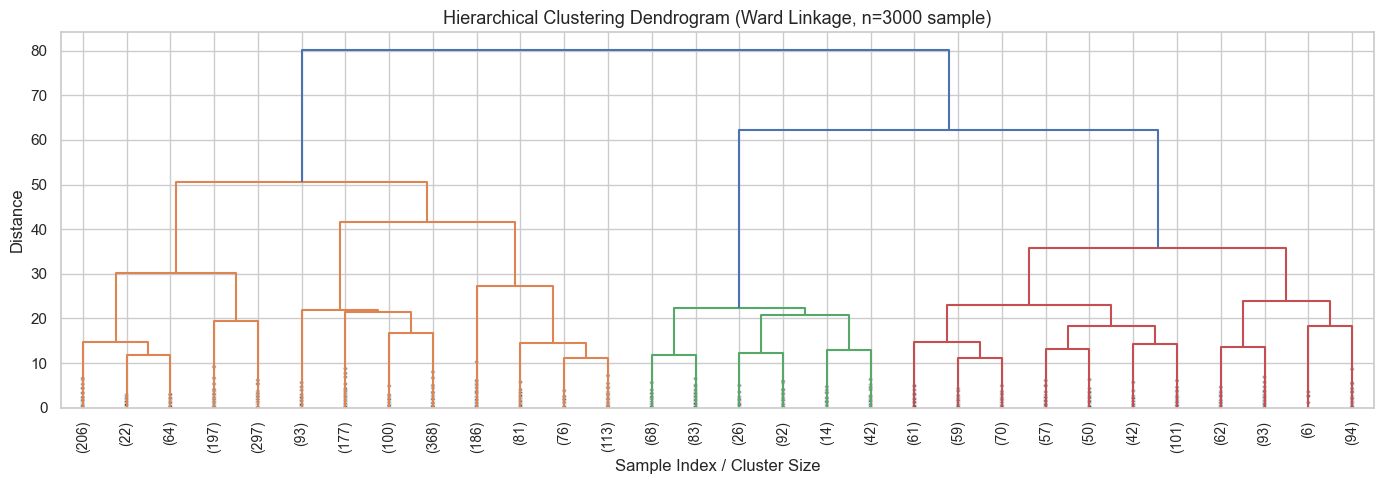

In [43]:
# Dendrogram on the sample
linkage_matrix = linkage(x_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, n=3000 sample)', fontsize=13)
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

> t-SNE

In [44]:
from sklearn.manifold import TSNE

In [45]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

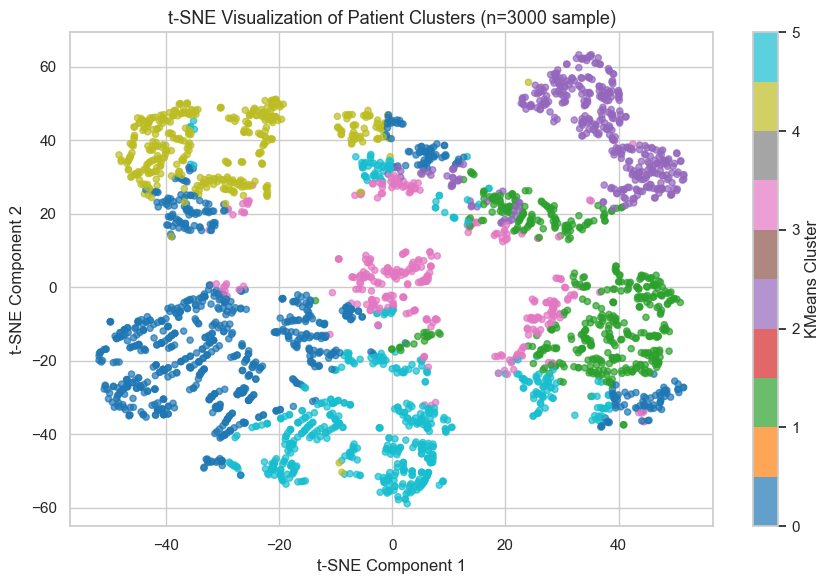

In [46]:
tsne_sample_idx = np.random.choice(len(x_scaled), size=3000, replace=False)
x_tsne_sample = x_scaled[tsne_sample_idx]
kmean_sample = data['kmean'].values[tsne_sample_idx]

tsne_result = tsne.fit_transform(x_tsne_sample)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    tsne_result[:, 0], tsne_result[:, 1],
    c=kmean_sample, cmap='tab10', alpha=0.7, s=20
)
plt.colorbar(scatter, label='KMeans Cluster')
plt.title('t-SNE Visualization of Patient Clusters (n=3000 sample)', fontsize=13)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

# Cluster profiles — clinical statistics per cluster

In [47]:
dataEda['kmean'] = data['kmean'].values

In [48]:
cluster_profiles = dataEda.groupby('kmean')[['age', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'cardio']].mean()
print('Cluster Profiles — Mean Clinical Statistics:')
cluster_profiles

Cluster Profiles — Mean Clinical Statistics:


,age,weight,ap_hi,ap_lo,cholesterol,cardio
kmean,,,,,,
0,57.674452,68.669792,121.553278,79.248991,1.083252,0.449277
1,55.091171,76.630755,152.535306,94.221923,1.278797,0.846383
2,56.151587,78.125466,132.908508,84.258497,2.843687,0.752870
3,52.627086,97.866310,128.821298,82.828337,1.199687,0.566215
4,47.911930,66.215805,107.237722,67.085862,1.156495,0.189162
5,45.517856,69.494706,122.367548,81.267367,1.099239,0.315176


# Silhouette score

In [49]:
from sklearn.metrics import silhouette_score

In [50]:
# Compute silhouette score on a sample for performance
sil_idx = np.random.choice(len(x_scaled), size=5000, replace=False)
sil_score = silhouette_score(x_scaled[sil_idx], data['kmean'].values[sil_idx])
print(f'KMeans Silhouette Score (n=5000 sample): {sil_score:.4f}')

KMeans Silhouette Score (n=5000 sample): 0.2210


# Supervised ML

In [51]:
x_sup = data.drop(columns=['cardio', 'dbscan', 'kmean'])
y_sup = data['cardio']
x_train, x_test, y_train, y_test = train_test_split(
    x_sup, y_sup, test_size=0.2, stratify=y_sup, random_state=42
)
print('Train size:', x_train.shape, '| Test size:', x_test.shape)

Train size: (55520, 11) | Test size: (13880, 11)


## Logistic Regression with regularization

In [52]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_model.fit(x_train, y_train)
lr_y_pred = lr_model.predict(x_test)

## Random Forest with feature importance

In [53]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(x_train, y_train)
rf_y_pred = rf_model.predict(x_test)

## XGBoost with hyperparameter tuning (n_estimators=500, max_depth=8)

In [54]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_model.fit(x_train, y_train)
xgb_y_pred = xgb_model.predict(x_test)

## Evaluate using stratified 5-fold cross-validation with AUC-ROC

In [55]:
def evaluate_model(name, model, y_true, y_pred, x_for_proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    if x_for_proba is not None:
        auc = roc_auc_score(y_true, model.predict_proba(x_for_proba)[:, 1])
    else:
        auc = None
    print(f'=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    if auc: print(f'AUC-ROC  : {auc:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'Disease'],
                yticklabels=['Healthy', 'Disease'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    return acc, auc, f1

=== Logistic Regression ===
Accuracy : 0.7272
AUC-ROC  : 0.7925
F1-Score : 0.7100
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6940
           1       0.76      0.67      0.71      6940

    accuracy                           0.73     13880
   macro avg       0.73      0.73      0.73     13880
weighted avg       0.73      0.73      0.73     13880



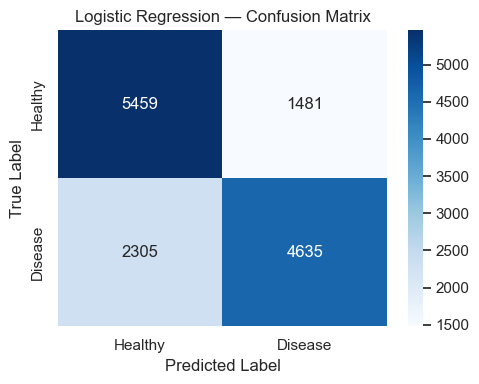

In [56]:
lr_acc, lr_auc, lr_f1 = evaluate_model('Logistic Regression', lr_model, y_test, lr_y_pred, x_test)

=== Random Forest ===
Accuracy : 0.7103
AUC-ROC  : 0.7694
F1-Score : 0.7087
              precision    recall  f1-score   support

           0       0.71      0.72      0.71      6940
           1       0.71      0.70      0.71      6940

    accuracy                           0.71     13880
   macro avg       0.71      0.71      0.71     13880
weighted avg       0.71      0.71      0.71     13880



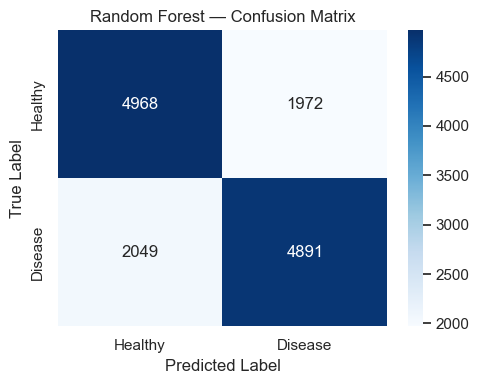

In [57]:
rf_acc, rf_auc, rf_f1 = evaluate_model('Random Forest', rf_model, y_test, rf_y_pred, x_test)

=== XGBoost ===
Accuracy : 0.7348
AUC-ROC  : 0.7982
F1-Score : 0.7235
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6940
           1       0.76      0.69      0.72      6940

    accuracy                           0.73     13880
   macro avg       0.74      0.73      0.73     13880
weighted avg       0.74      0.73      0.73     13880



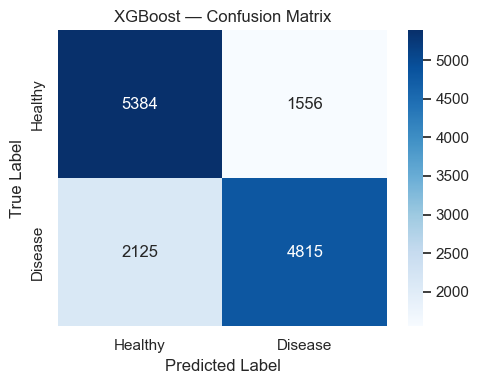

In [58]:
xgb_acc, xgb_auc, xgb_f1 = evaluate_model('XGBoost', xgb_model, y_test, xgb_y_pred, x_test)

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5)

for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest', rf_model),
                     ('XGBoost', xgb_model)]:
    cv_scores = cross_val_score(model, x_sup, y_sup, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name} — CV AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic Regression — CV AUC-ROC: 0.7910 ± 0.0055
Random Forest — CV AUC-ROC: 0.7683 ± 0.0024
XGBoost — CV AUC-ROC: 0.7964 ± 0.0047


## Calibration curves

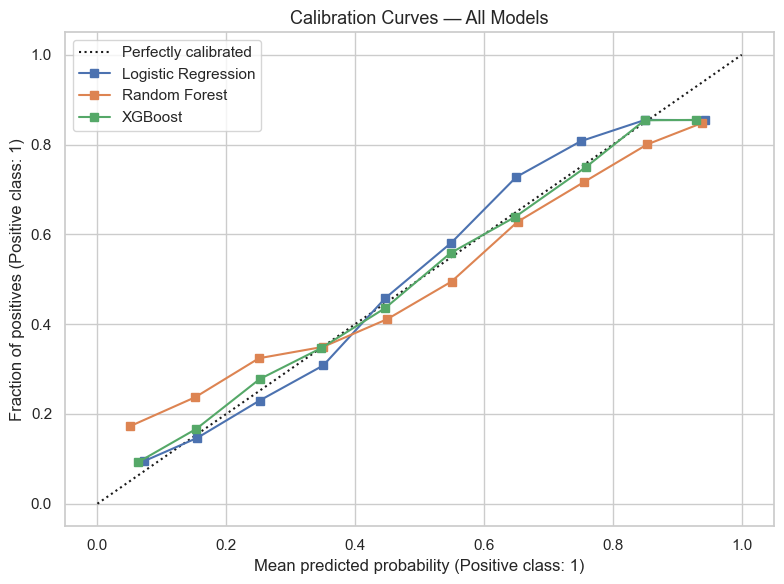

In [60]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest', rf_model),
                     ('XGBoost', xgb_model)]:
    CalibrationDisplay.from_estimator(model, x_test, y_test, n_bins=10, ax=ax, name=name)

ax.set_title('Calibration Curves — All Models', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance

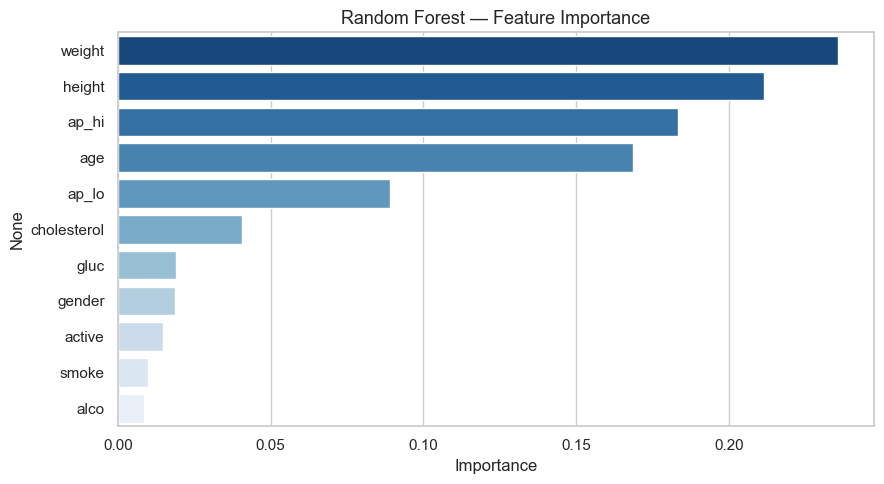

In [61]:
# Random Forest feature importance
rf_importances = pd.Series(rf_model.feature_importances_, index=x_sup.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=rf_importances_sorted.values, y=rf_importances_sorted.index, palette='Blues_r')
plt.title('Random Forest — Feature Importance', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

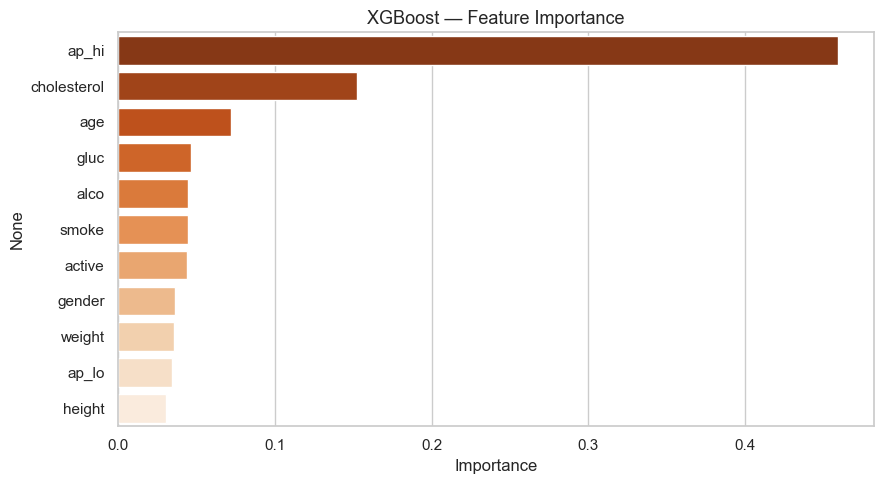

In [62]:
# XGBoost feature importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=x_sup.columns)
xgb_importances_sorted = xgb_importances.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=xgb_importances_sorted.values, y=xgb_importances_sorted.index, palette='Oranges_r')
plt.title('XGBoost — Feature Importance', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Compare model performance

In [63]:
ml_results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [round(lr_acc, 4), round(rf_acc, 4), round(xgb_acc, 4)],
    'AUC-ROC':  [round(lr_auc, 4), round(rf_auc, 4), round(xgb_auc, 4)],
    'F1-Score': [round(lr_f1, 4),  round(rf_f1, 4),  round(xgb_f1, 4)]
})
print(ml_results.to_string(index=False))

              Model  Accuracy  AUC-ROC  F1-Score
Logistic Regression    0.7272   0.7925    0.7100
      Random Forest    0.7103   0.7694    0.7087
            XGBoost    0.7348   0.7982    0.7235


# ML models save

In [64]:
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl', compress=9)
joblib.dump(xgb_model, 'xgboost_model.pkl')
print('ML models saved successfully.')

ML models saved successfully.


# Deep Learning

In [65]:
dl_features = data.drop(columns=['cardio', 'dbscan', 'kmean'])
dl_target   = data['cardio']

x_train_dl, x_test_dl, y_train_dl, y_test_dl = train_test_split(
    dl_features, dl_target, test_size=0.2, stratify=dl_target, random_state=42
)
print('DL Train size:', x_train_dl.shape, '| DL Test size:', x_test_dl.shape)

DL Train size: (55520, 11) | DL Test size: (13880, 11)


In [66]:
scaler_dl = StandardScaler()
x_train_dl = scaler_dl.fit_transform(x_train_dl)
x_test_dl  = scaler_dl.transform(x_test_dl)

### Baseline DNN Classifier (5 hidden layers: 256, 128, 64, 32, 16)

In [67]:
modelBL = Sequential([
    Dense(256, activation='relu', input_shape=(x_train_dl.shape[1],)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(64,  activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(32,  activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(16,  activation='relu'),
    Dense(1,   activation='sigmoid')
])
modelBL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,769 (190.50 KB)

 Trainable params: 47,809 (186.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [68]:
modelBL.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [69]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [70]:
history = modelBL.fit(
    x_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=100, batch_size=256,
    callbacks=[es], verbose=1
)

Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.6561 - loss: 0.6319 - val_accuracy: 0.7199 - val_loss: 0.5726
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7233 - loss: 0.5626 - val_accuracy: 0.7236 - val_loss: 0.5517
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7230 - loss: 0.5623 - val_accuracy: 0.7270 - val_loss: 0.5496
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7234 - loss: 0.5581 - val_accuracy: 0.7266 - val_loss: 0.5492
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7310 - loss: 0.5525 - val_accuracy: 0.7301 - val_loss: 0.5476
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7327 - loss: 0.5497 - val_accuracy: 0.7285 - val_loss: 0.5490
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7281 - loss: 0.5526 - val_accuracy: 0.7289 - val_loss: 0.5476
Epoch 8/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7310 - loss: 0.5483 -

In [71]:
bl_loss, bl_acc_val = modelBL.evaluate(x_test_dl, y_test_dl, verbose=0)
bl_proba = modelBL.predict(x_test_dl, verbose=0).ravel()
bl_auc   = roc_auc_score(y_test_dl, bl_proba)
bl_acc   = accuracy_score(y_test_dl, (bl_proba >= 0.5).astype(int))
print(f'Baseline DNN — Accuracy: {bl_acc:.4f} | AUC-ROC: {bl_auc:.4f}')

Baseline DNN — Accuracy: 0.7327 | AUC-ROC: 0.8004


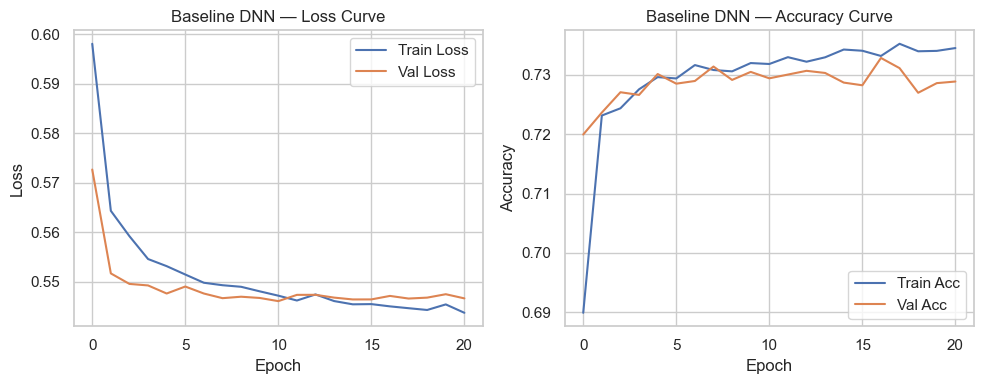

In [72]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Baseline DNN — Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Baseline DNN — Accuracy Curve')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()

### Wide & Deep Architecture

In [73]:
input_wd = Input(shape=(x_train_dl.shape[1],), name='input')

# Wide path
wide = Dense(x_train_dl.shape[1], activation='linear', name='wide')(input_wd)

# Deep path
deep = Dense(256, activation='relu', name='deep_1')(input_wd)
deep = Dense(128, activation='relu', name='deep_2')(deep)
deep = Dense(64,  activation='relu', name='deep_3')(deep)

# Concatenate
concat = concatenate([wide, deep], name='concat')
output_wd = Dense(1, activation='sigmoid', name='output')(concat)

modelWD = Model(inputs=input_wd, outputs=output_wd)
modelWD.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 11)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_1 (Dense)      │ (None, 256)       │      3,072 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_2 (Dense)      │ (None, 128)       │     32,896 │ deep_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide (Dense)        │ (None, 11)        │        132 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_3 (Dense)      │ (None, 64)        │      8,256 │ deep_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 75)        │          0 │ wide[0][0],       │
│ (Concatenate)       │                   │            │ deep_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         76 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,432 (173.56 KB)

 Trainable params: 44,432 (173.56 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
modelWD.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_wd = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_wd = modelWD.fit(
    x_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=100, batch_size=256,
    callbacks=[es_wd], verbose=1
)

Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6770 - loss: 0.5935 - val_accuracy: 0.7279 - val_loss: 0.5494
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7302 - loss: 0.5463 - val_accuracy: 0.7245 - val_loss: 0.5496
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7332 - loss: 0.5432 - val_accuracy: 0.7260 - val_loss: 0.5476
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7362 - loss: 0.5409 - val_accuracy: 0.7300 - val_loss: 0.5474
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7345 - loss: 0.5398 - val_accuracy: 0.7287 - val_loss: 0.5476
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7337 - loss: 0.5428 - val_accuracy: 0.7311 - val_loss: 0.5471
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7365 - loss: 0.5382 - val_accuracy: 0.7305 - val_loss: 0.5482
Epoch 8/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7380 - loss: 0.5385 -

In [75]:
wd_proba = modelWD.predict(x_test_dl, verbose=0).ravel()
wd_auc   = roc_auc_score(y_test_dl, wd_proba)
wd_acc   = accuracy_score(y_test_dl, (wd_proba >= 0.5).astype(int))
print(f'Wide & Deep — Accuracy: {wd_acc:.4f} | AUC-ROC: {wd_auc:.4f}')

Wide & Deep — Accuracy: 0.7329 | AUC-ROC: 0.8000


# Autoencoder for unsupervised feature learning (12→8→4→8→12)

In [76]:
input_dim   = x_train_dl.shape[1]
input_layer = Input(shape=(input_dim,))
enc         = Dense(8, activation='relu')(input_layer)
bottleneck  = Dense(4, activation='relu')(enc)
dec         = Dense(8, activation='relu')(bottleneck)
output_layer= Dense(input_dim, activation='linear')(dec)

autoencoder = Model(input_layer, output_layer)
encoder     = Model(input_layer, bottleneck)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
autoencoder.compile(optimizer='adam', loss='mse')

In [78]:
autoencoder.fit(
    x_train_dl, x_train_dl,
    epochs=50, batch_size=256,
    validation_split=0.2, verbose=1
)

Epoch 1/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 1.1457 - val_loss: 0.9639
Epoch 2/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9071 - val_loss: 0.7339
Epoch 3/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6926 - val_loss: 0.6131
Epoch 4/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5985 - val_loss: 0.5679
Epoch 5/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5600 - val_loss: 0.5372
Epoch 6/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5296 - val_loss: 0.5060
Epoch 7/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5030 - val_loss: 0.4708
Epoch 8/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4619 - val_loss: 0.4308
Epoch 9/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4162 - val_loss: 0.3949
Epoch 10/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3897 - val_loss: 0.3820
Epoch 11/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3751 - val_loss: 0.3728
Epoch 12/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

In [79]:
enc_train = encoder.predict(x_train_dl, verbose=0)
enc_test  = encoder.predict(x_test_dl,  verbose=0)

enc_train = pd.DataFrame(enc_train, columns=[f'enc_{i}' for i in range(4)])
enc_test  = pd.DataFrame(enc_test,  columns=[f'enc_{i}' for i in range(4)])
print('Encoded train shape:', enc_train.shape)

Encoded train shape: (55520, 4)


> Added cluster memberships

In [80]:
train_df = pd.DataFrame(x_train_dl, columns=dl_features.columns)
test_df  = pd.DataFrame(x_test_dl,  columns=dl_features.columns)

In [81]:
# Recover train/test indices from the split to assign kmean/dbscan cluster labels
dl_features_reset = dl_features.reset_index(drop=True)
_, _, _, _, train_idx, test_idx = train_test_split(
    dl_features_reset, dl_target,
    dl_features_reset.index, test_size=0.2,
    stratify=dl_target, random_state=42
)

train_df['kmean']  = data['kmean'].values[train_idx]
train_df['dbscan'] = data['dbscan'].values[train_idx]
test_df['kmean']   = data['kmean'].values[test_idx]
test_df['dbscan']  = data['dbscan'].values[test_idx]

In [82]:
x_train_final = pd.concat([train_df, enc_train], axis=1).reset_index(drop=True)
x_test_final  = pd.concat([test_df,  enc_test],  axis=1).reset_index(drop=True)
print('x_train_final shape:', x_train_final.shape)
print('x_test_final  shape:', x_test_final.shape)

x_train_final shape: (55520, 17)
x_test_final  shape: (13880, 17)


# DNN After Autoencoder

In [83]:
modelAE = Sequential([
    Dense(256, activation='relu', input_shape=(x_train_final.shape[1],)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(64,  activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(32,  activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(16,  activation='relu'),
    Dense(1,   activation='sigmoid')
])
modelAE.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelAE.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,305 (196.50 KB)

 Trainable params: 49,345 (192.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [84]:
es_ae = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_ae = modelAE.fit(
    x_train_final, y_train_dl,
    validation_split=0.2,
    epochs=100, batch_size=256,
    callbacks=[es_ae], verbose=1
)

Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.6341 - loss: 0.6733 - val_accuracy: 0.7150 - val_loss: 0.5699
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7098 - loss: 0.5817 - val_accuracy: 0.7196 - val_loss: 0.5596
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7233 - loss: 0.5617 - val_accuracy: 0.7243 - val_loss: 0.5530
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7166 - loss: 0.5653 - val_accuracy: 0.7239 - val_loss: 0.5526
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7278 - loss: 0.5561 - val_accuracy: 0.7244 - val_loss: 0.5517
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7281 - loss: 0.5555 - val_accuracy: 0.7262 - val_loss: 0.5501
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7259 - loss: 0.5569 - val_accuracy: 0.7282 - val_loss: 0.5496
Epoch 8/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7277 - loss: 0.5542 -

In [85]:
ae_proba = modelAE.predict(x_test_final, verbose=0).ravel()
ae_auc   = roc_auc_score(y_test_dl, ae_proba)
ae_acc   = accuracy_score(y_test_dl, (ae_proba >= 0.5).astype(int))
print(f'DNN + Autoencoder — Accuracy: {ae_acc:.4f} | AUC-ROC: {ae_auc:.4f}')

DNN + Autoencoder — Accuracy: 0.7347 | AUC-ROC: 0.8009


# Deep Learning vs Traditional Ensemble Methods

In [86]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'DNN Baseline',
        'DNN + Autoencoder',
        'Wide & Deep'
    ],
    'Accuracy': [
        round(lr_acc,  4), round(rf_acc,  4), round(xgb_acc, 4),
        round(bl_acc,  4), round(ae_acc,  4), round(wd_acc,  4)
    ],
    'AUC-ROC': [
        round(lr_auc,  4), round(rf_auc,  4), round(xgb_auc, 4),
        round(bl_auc,  4), round(ae_auc,  4), round(wd_auc,  4)
    ]
})
print(final_results.to_string(index=False))

              Model  Accuracy  AUC-ROC
Logistic Regression    0.7272   0.7925
      Random Forest    0.7103   0.7694
            XGBoost    0.7348   0.7982
       DNN Baseline    0.7327   0.8004
  DNN + Autoencoder    0.7347   0.8009
        Wide & Deep    0.7329   0.8000


# DL models save

In [87]:
modelBL.save('deep_learning_baseline_model.h5')
modelAE.save('deep_learning_autoencoder_model.h5')
modelWD.save('wide_deep_model.h5')
joblib.dump(scaler_dl, 'scaler_dl.pkl')
joblib.dump(scaler,    'scaler.pkl')
print('All Deep Learning models and scalers saved successfully.')

All Deep Learning models and scalers saved successfully.
